# OncoPrint

[OncoPrint](http://www.cbioportal.org/faq#what-are-oncoprints) is a way to visualize multiple genomic alteration events using a heatmap-like display. The **complexheatmap** package provides `oncoPrint()` which generates oncoPrints with barplots on both sides showing the number of different alterations for each sample and each gene.

This tutorial covers: input data formats, defining `alter_fun`, custom colors, annotations, sample ordering, and using the built-in TCGA dataset.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import (
    oncoPrint, alter_graphic, test_alter_fun,
    HeatmapAnnotation, rowAnnotation, anno_barplot,
    load_tcga_oncoprint, color_ramp2
)
import grid_py as gp

## Input Data Format

There are two ways to provide alteration data:

**1. A string matrix** where each cell contains semicolon-separated alteration types (e.g., `"snv;indel"`). Empty strings mean no alteration.

**2. A list of binary matrices** where each matrix represents one alteration type (1 = present, 0 = absent).

Separators `;:,|` are automatically recognized, so `get_type` usually does not need to be specified.

In [2]:
# Example: string matrix format
mat = np.array([
    ["snv;indel", "snv",       "indel"],
    ["",          "snv;indel", "snv"],
    ["snv",       "",          "indel;snv"],
])

# Row names = genes, column names = samples
mat = pd.DataFrame(mat,
    index=["g1", "g2", "g3"],
    columns=["s1", "s2", "s3"]
)
print(mat)

           s1         s2         s3
g1  snv;indel        snv      indel
g2             snv;indel        snv
g3        snv             indel;snv


## Defining `alter_fun`

For each alteration type, you define how it is drawn in a cell. The function receives `(x, y, w, h)` -- position and size of the cell in the oncoPrint.

`alter_fun` can be:
- A **dict** of functions keyed by alteration type (layer-by-layer drawing)
- A **single function** that receives an additional argument `v` (a dict of booleans for each type)

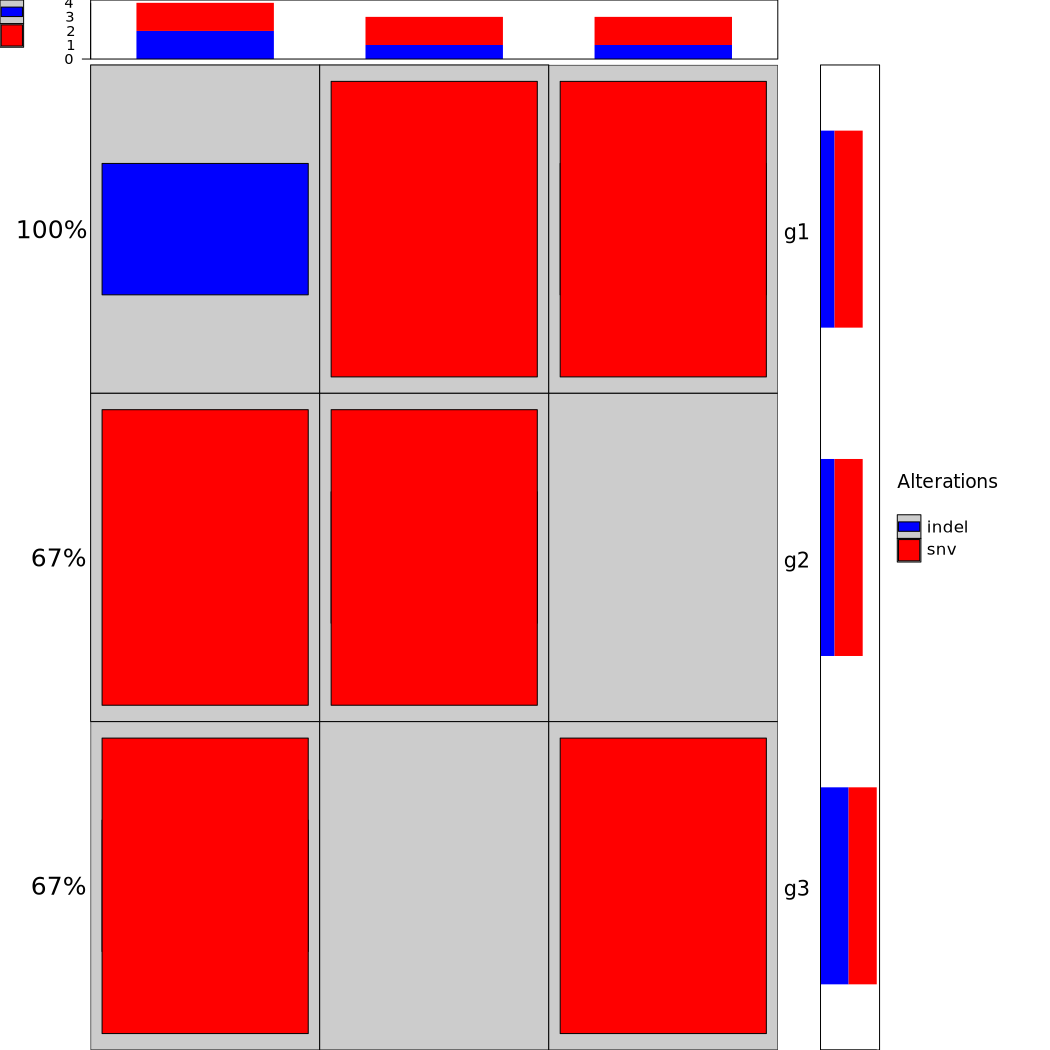

In [3]:
col = {"snv": "red", "indel": "blue"}

alter_fun_dict = {
    "snv": lambda x, y, w, h: gp.grid_rect(
        x, y, w * 0.9, h * 0.9,
        gp={"fill": col["snv"], "col": None}),
    "indel": lambda x, y, w, h: gp.grid_rect(
        x, y, w * 0.9, h * 0.4,
        gp={"fill": col["indel"], "col": None}),
}

ht = oncoPrint(mat.values, name="OncoPrint",
               alter_fun=alter_fun_dict,
               col=col,
               row_labels=list(mat.index))
ht.draw()

### Single-function `alter_fun`

As an alternative, a single function can handle all types. The fifth argument `v` is a dict of booleans.

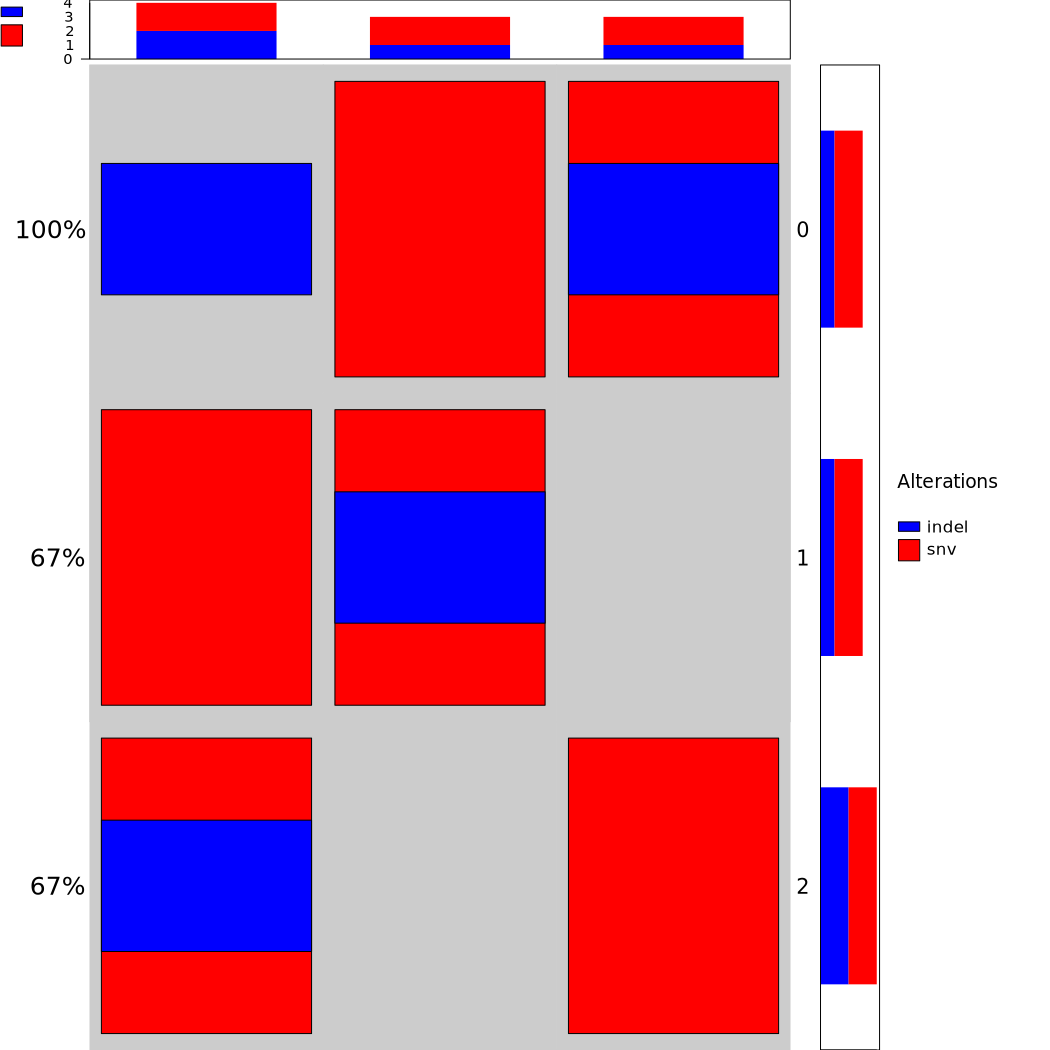

In [4]:
def my_alter_fun(x, y, w, h, v):
    if v.get("snv", False):
        gp.grid_rect(x, y, w * 0.9, h * 0.9,
                     gp={"fill": col["snv"], "col": None})
    if v.get("indel", False):
        gp.grid_rect(x, y, w * 0.9, h * 0.4,
                     gp={"fill": col["indel"], "col": None})

ht = oncoPrint(mat.values, name="OncoPrint2",
               alter_fun=my_alter_fun,
               col=col)
ht.draw()

## Using `alter_graphic`

For simple cases, `alter_graphic` provides a convenient shortcut to create alter functions with predefined shapes.

In [5]:
print(f"alter_graphic is callable: {callable(alter_graphic)}")
print(f"test_alter_fun is callable: {callable(test_alter_fun)}")

alter_graphic is callable: True
test_alter_fun is callable: True


## Loading Built-in TCGA Data

The package includes a TCGA oncoprint dataset for demonstration.

In [6]:
onco_df = load_tcga_oncoprint()
print(f"Shape: {onco_df.shape}")
print(f"Genes (first 5): {list(onco_df.index[:5])}")
print(f"Samples (first 5): {list(onco_df.columns[:5])}")
onco_df.head()

Shape: (26, 172)
Genes (first 5): ['KRAS', 'HRAS', 'BRAF', 'RAF1', 'MAP3K1']
Samples (first 5): ['TCGA-05-4384-01', 'TCGA-05-4390-01', 'TCGA-05-4425-01', 'TCGA-38-4631-01', 'TCGA-38-4632-01']


,TCGA-05-4384-01,TCGA-05-4390-01,TCGA-05-4425-01,TCGA-38-4631-01,TCGA-38-4632-01,TCGA-38-6178-01,TCGA-44-6144-01,TCGA-44-6145-01,TCGA-44-6146-01,TCGA-44-6147-01,...,TCGA-55-5899-01,TCGA-64-5774-01,TCGA-64-5775-01,TCGA-64-5778-01,TCGA-64-5779-01,TCGA-64-5781-01,TCGA-64-5815-01,TCGA-75-5146-01,TCGA-75-5147-01,TCGA-80-5611-01
KRAS,NaN,MUT;,NaN,NaN,NaN,NaN,MUT;,MUT;,MUT;,NaN,...,NaN,MUT;,MUT;,MUT;,NaN,NaN,MUT;,NaN,NaN,NaN
HRAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,HOMDEL;,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BRAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AMP;,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MUT;,NaN,NaN
RAF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MAP3K1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Basic oncoPrint from TCGA data
ht = oncoPrint(onco_df.to_numpy(), name="OncoPrint")
ht.make_layout()
print(f"nrow: {ht.nrow}, ncol: {ht.ncol}")

nrow: 26, ncol: 172


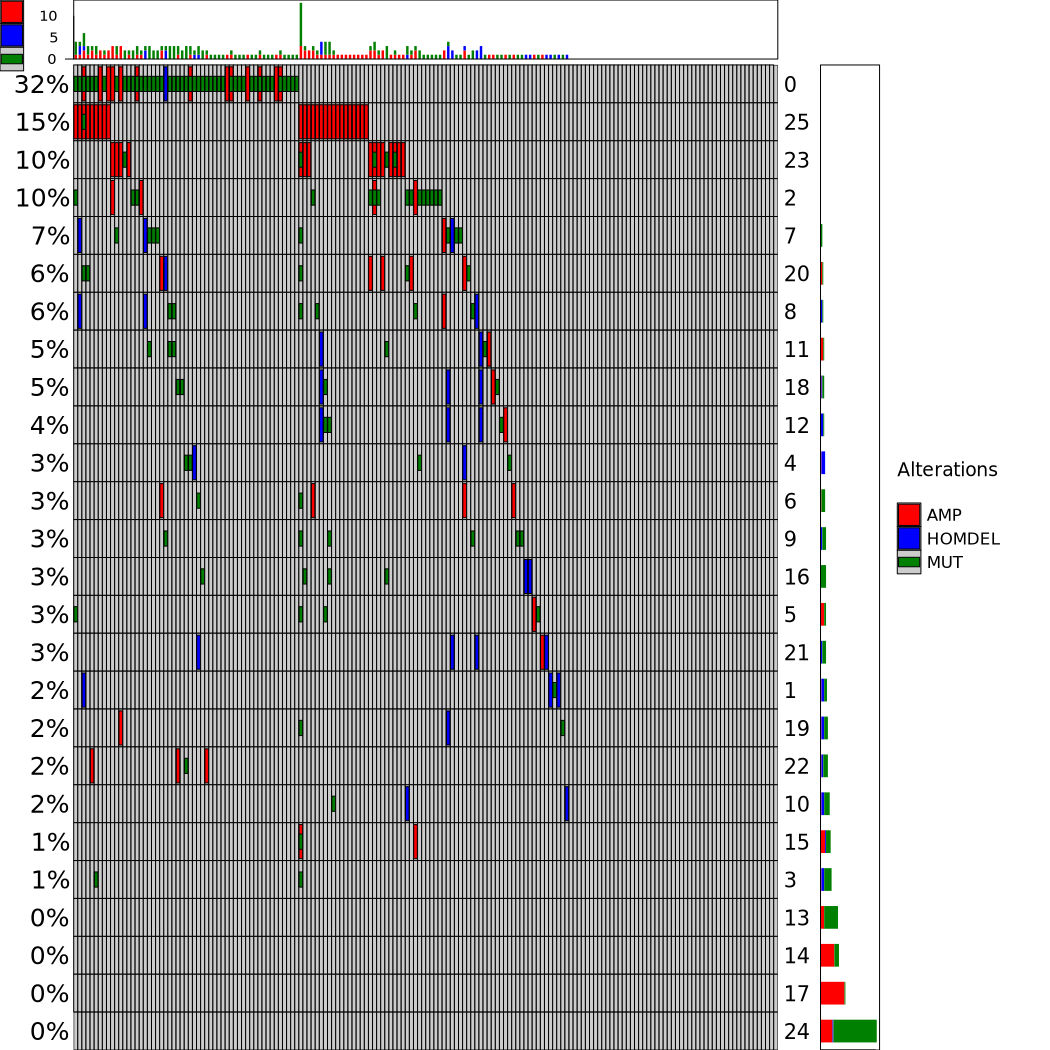

In [8]:
ht.draw()

## OncoPrint with Row Labels

Use `row_labels` to display gene names on the heatmap rows.

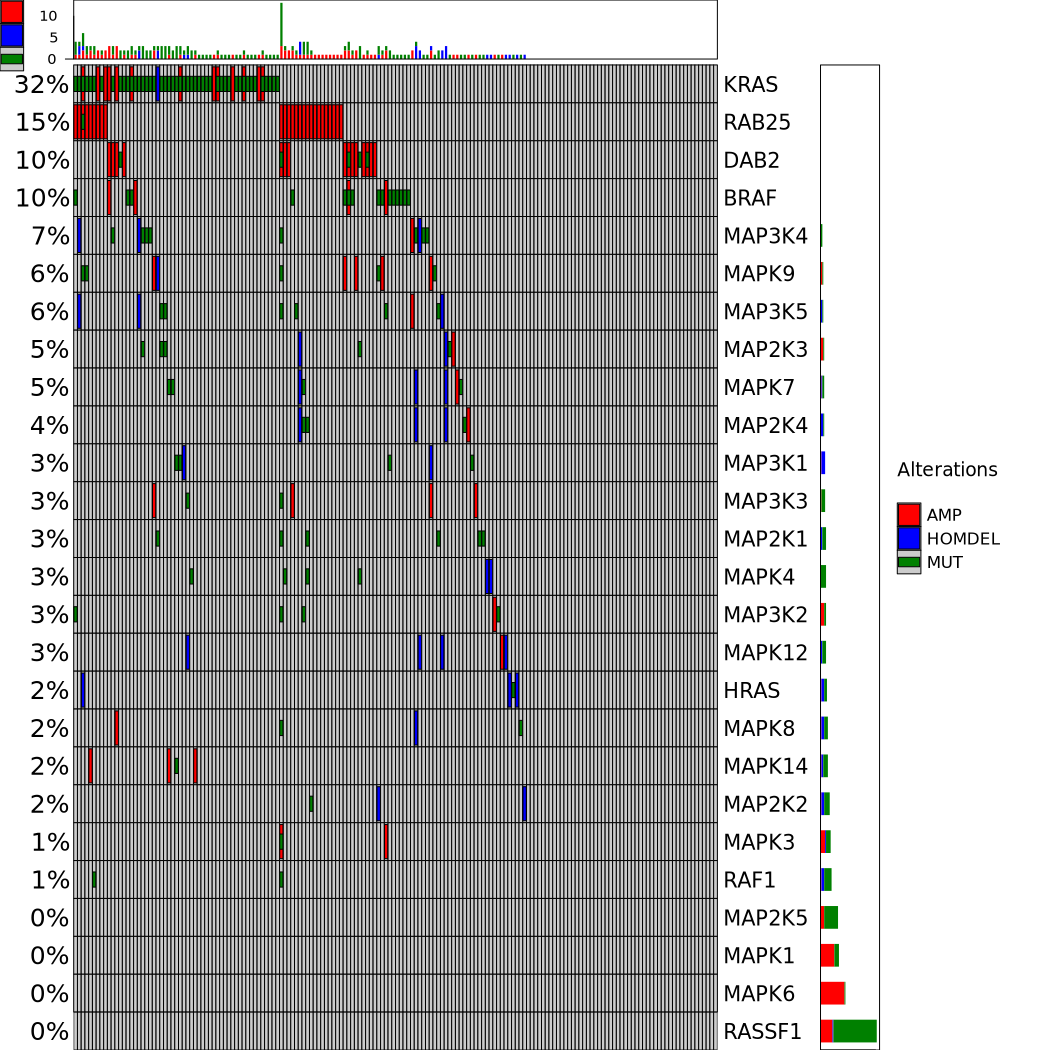

In [9]:
genes = list(onco_df.index)
ht = oncoPrint(onco_df.to_numpy(), name="OncoPrint",
               row_labels=genes)
ht.draw()

## Removing Empty Columns

Some samples may have no alterations in any of the selected genes. `remove_empty_columns=True` filters them out.

In [10]:
ht_full = oncoPrint(onco_df.to_numpy(), name="full")
ht_full.make_layout()

ht_trimmed = oncoPrint(onco_df.to_numpy(), name="trimmed",
                       remove_empty_columns=True)
ht_trimmed.make_layout()

print(f"Before removal: {ht_full.ncol} columns")
print(f"After removal:  {ht_trimmed.ncol} columns")

Before removal: 172 columns
After removal:  121 columns


## Adding Annotations to OncoPrint

Like regular heatmaps, oncoPrints support `top_annotation`, `bottom_annotation`, `left_annotation`, and `right_annotation`. The default oncoPrint already includes barplot annotations showing alteration counts.

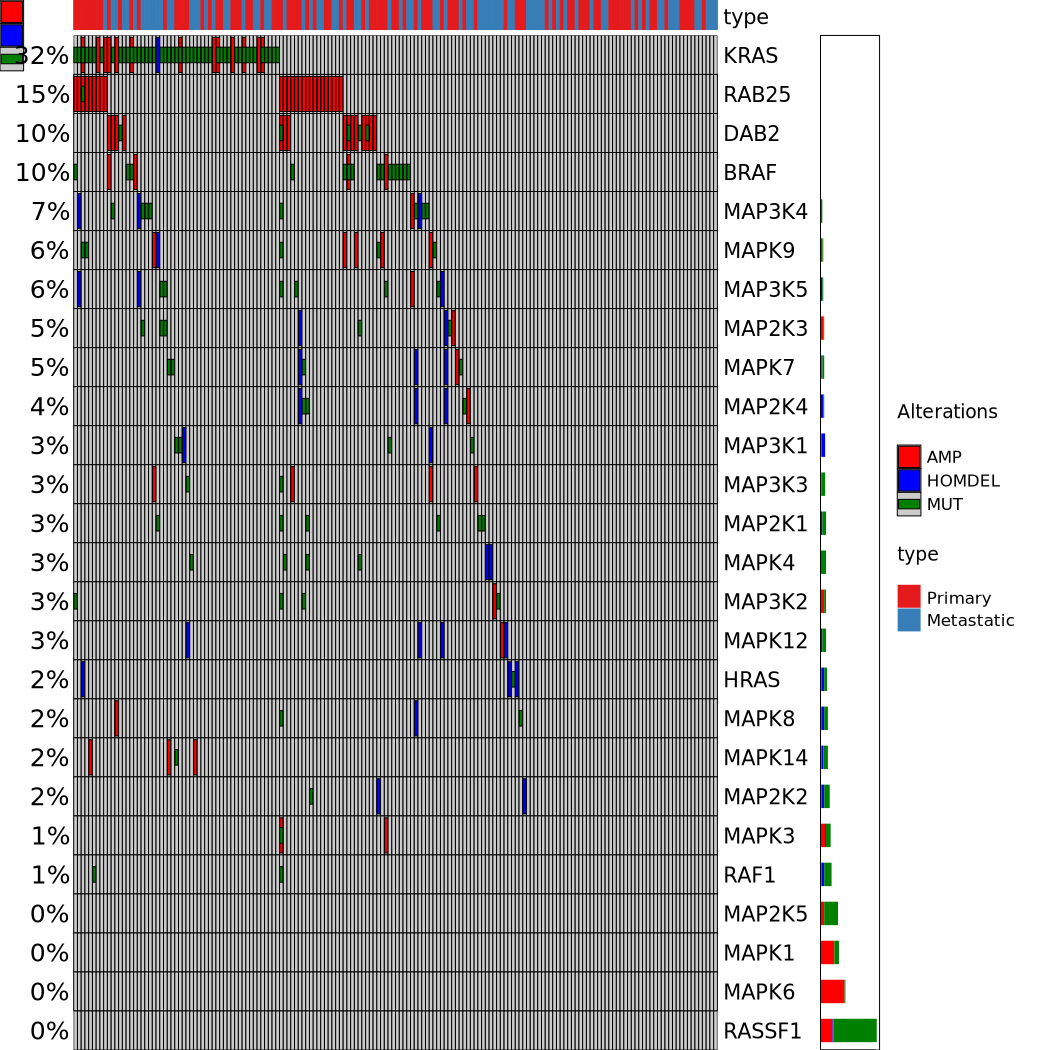

In [11]:
# Custom annotation on top
n_samples = onco_df.shape[1]
sample_type = np.random.choice(["Primary", "Metastatic"], size=n_samples)

ha_top = HeatmapAnnotation(
    type=sample_type,
    col={"type": {"Primary": "#E41A1C", "Metastatic": "#377EB8"}}
)

ht = oncoPrint(onco_df.to_numpy(), name="OncoPrint",
               top_annotation=ha_top,
               row_labels=genes)
ht.draw()

## Binary Matrix List Input

The second input format uses a dict of binary matrices, one per alteration type.

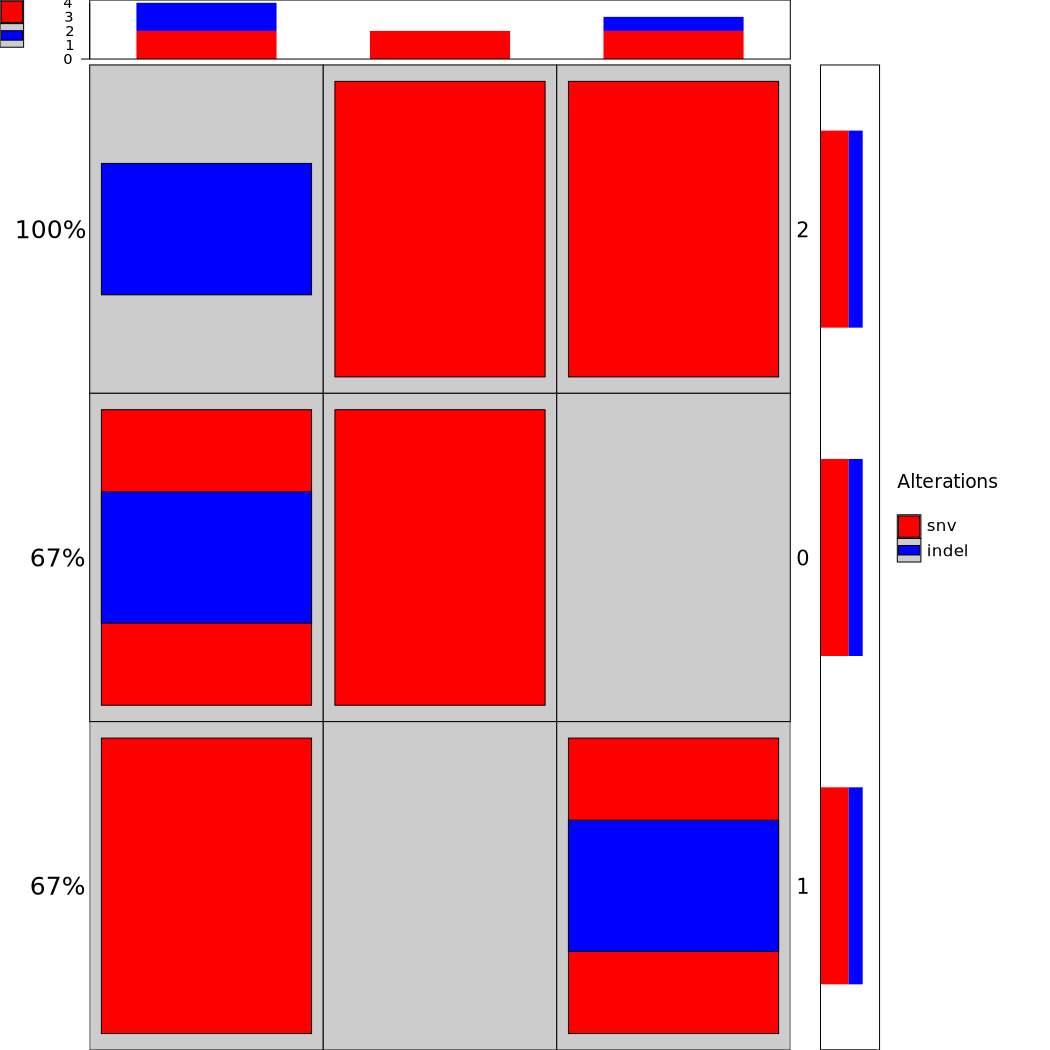

In [12]:
mat_list = {
    "snv": np.array([[1, 0, 1],
                     [1, 1, 0],
                     [0, 1, 1]]),
    "indel": np.array([[1, 0, 0],
                       [0, 1, 0],
                       [1, 0, 0]])
}

ht = oncoPrint(mat_list, name="OncoPrint_list",
               alter_fun=alter_fun_dict,
               col=col)
ht.draw()

## Summary

This tutorial covered:

- Two input formats: string matrix and dict of binary matrices
- `alter_fun` as a dict of per-type functions or a single multi-type function
- `alter_graphic` and `test_alter_fun` utility functions
- Built-in TCGA oncoprint data via `load_tcga_oncoprint()`
- Dimension verification with `nrow` and `ncol`
- Adding row labels with `row_labels`
- Removing empty columns with `remove_empty_columns`
- Custom annotations on oncoPrints